## IMPORT LIBRARIES

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load the cleaned CSV
df = pd.read_csv(r"C:\Users\karth\Downloads\TeamNumber_TeamName_cleaned_csv.csv", 
                  encoding='utf-8-sig')

## STEP 3: SELECT ANALYSIS COLUMN
Glucose chosen because it is the most important diabetes indicator in the dataset


## DESCRIPTIVE STATISTICS

In [11]:
column = 'Glucose'
print("===================================")
print("DESCRIPTIVE STATISTICS FOR GLUCOSE")
print("===================================")


DESCRIPTIVE STATISTICS FOR GLUCOSE


In [12]:
print(df.columns)

Index(['Patient_id', 'PID', 'Age', 'Gender', 'Race',
       'Average sleep duration (hrs)', 'Sleep quality (1-10)',
       '% with sleep disturbances', 'Date', 'Time', 'Glucose', 'Calories',
       'Heart_rate', 'Steps', 'Basal_rate', 'Bolus_dose', 'Carb_input'],
      dtype='object')


In [81]:
# COUNT
# -----------------------------
print("\nCOUNT")
print(df[column].count())


COUNT
309392


In [82]:
# MEAN
# -----------------------------
print("\nMEAN")
print(df[column].mean())


MEAN
141.4250511002224


In [83]:
# MEDIAN
# -----------------------------
print("\nMEDIAN")
print(df[column].median())


MEDIAN
132.0


In [84]:
# MODE
# -----------------------------
print("\nMODE")
print(df[column].mode())


MODE
0    113.0
Name: Glucose, dtype: float64


In [85]:
# MINIMUM VALUE
# -----------------------------
print("\nMINIMUM")
print(df[column].min())


MINIMUM
40.0


In [86]:
# MAXIMUM VALUE
# -----------------------------
print("\nMAXIMUM")
print(df[column].max())


MAXIMUM
444.0


In [87]:
# RANGE
# -----------------------------
print("\nRANGE")
print(df[column].max() - df[column].min())


RANGE
404.0


In [88]:
# VARIANCE
# -----------------------------
print("\nVARIANCE")
print(df[column].var())


VARIANCE
3258.764216176793


In [89]:
# STANDARD DEVIATION
# -----------------------------
print("\nSTANDARD DEVIATION")
print(df[column].std())


STANDARD DEVIATION
57.085586763882816


In [90]:
# FULL SUMMARY
# -----------------------------
print("\nFULL DESCRIPTIVE SUMMARY")
print(df[column].describe())


FULL DESCRIPTIVE SUMMARY
count    309392.000000
mean        141.425051
std          57.085587
min          40.000000
25%          99.666700
50%         132.000000
75%         173.000000
max         444.000000
Name: Glucose, dtype: float64


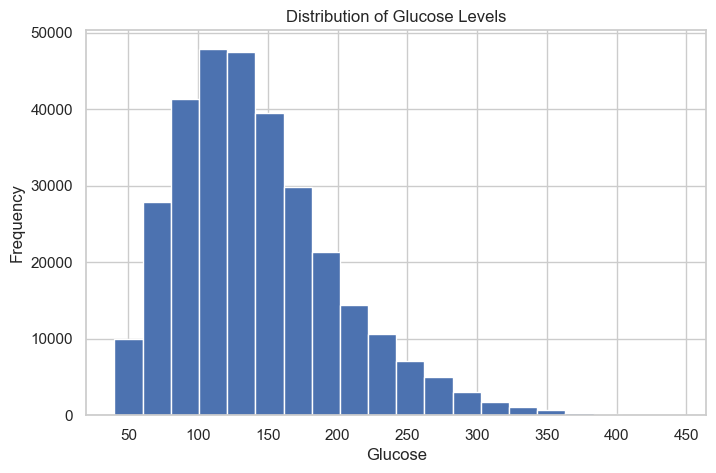

In [91]:
# VISUALIZATIONS
# =========================================================

# -----------------------------
# HISTOGRAM
# -----------------------------
plt.figure(figsize=(8,5))

plt.hist(df[column], bins=20)

plt.title('Distribution of Glucose Levels')

plt.xlabel('Glucose')

plt.ylabel('Frequency')

plt.show()

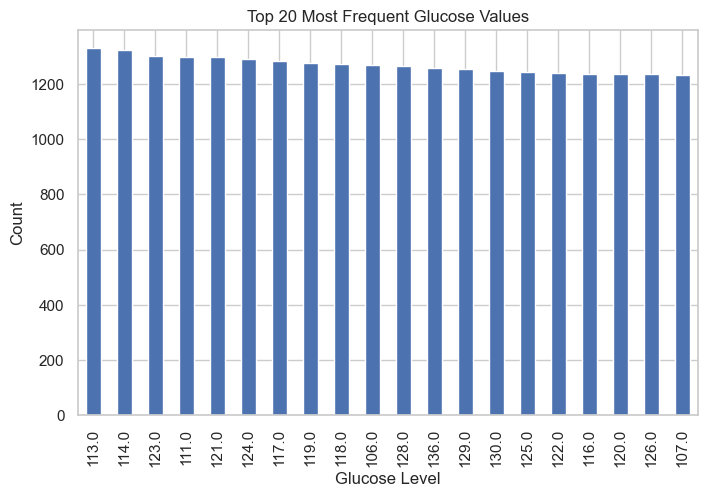

In [92]:
# FREQUENCY DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

df[column].value_counts().head(20).plot(kind='bar')

plt.title('Top 20 Most Frequent Glucose Values')

plt.xlabel('Glucose Level')

plt.ylabel('Count')

plt.show()

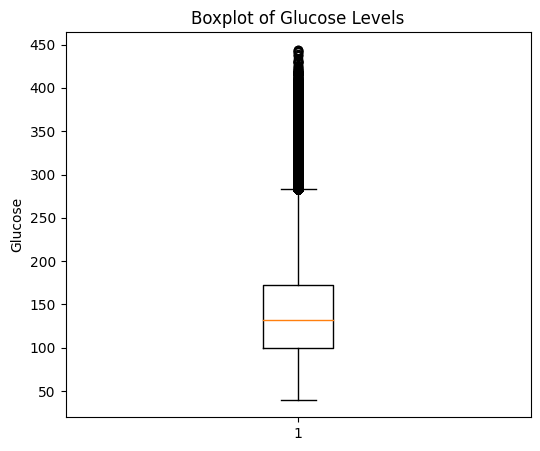

In [13]:
# BOXPLOT FOR OUTLIERS
# =========================================================

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

plt.boxplot(df[column])

plt.title('Boxplot of Glucose Levels')

plt.ylabel('Glucose')

plt.show()

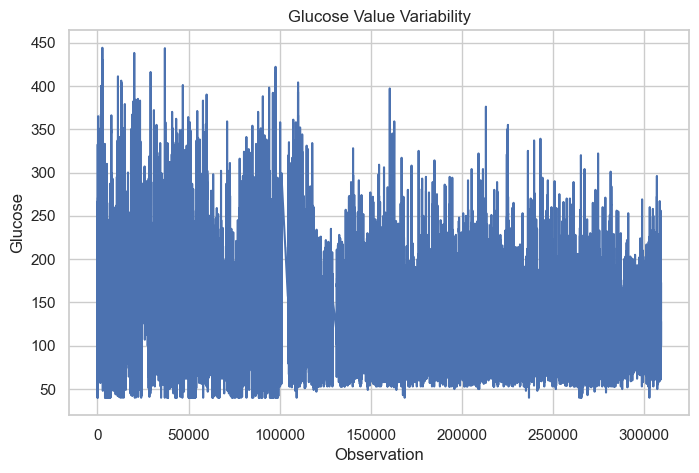

In [94]:
# VARIANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(df[column])

plt.title('Glucose Value Variability')

plt.xlabel('Observation')

plt.ylabel('Glucose')

plt.show()

# TIR / TAR / TBR by Age Group

## Why these biomarkers were chosen
- Glucose was selected because it directly reflects glycemic control quality.
- TIR, TAR, and TBR are clinically important metrics used in continuous glucose monitoring analysis.
- Age groups were included to evaluate how glucose regulation changes across different populations.

## Medical influence
- Higher TIR indicates better glucose stability and healthier metabolic control.
- Increased TAR may indicate prolonged hyperglycemia and higher diabetes complication risk.
- Increased TBR may indicate severe hypoglycemic risk and unstable glucose regulation.
- This analysis supports age-specific intervention and personalized glucose monitoring.

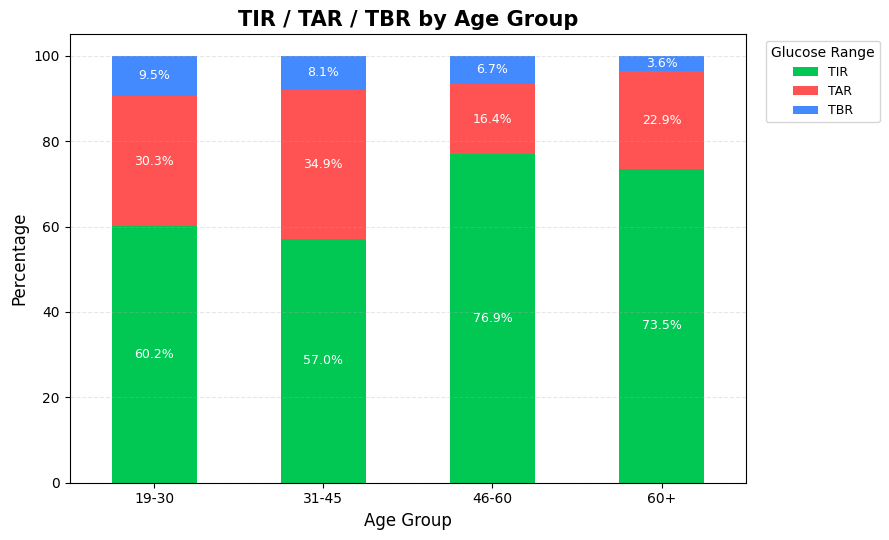

In [28]:
# TIR/TAR/TBR by Age Group

import matplotlib.pyplot as plt

# Create stacked dashboard chart
ax = dashboard.plot(
    kind="bar",
    stacked=True,

    figsize=(9,5.5),   # Increased size

    color=[
        "#00C853",   # TIR
        "#FF5252",   # TAR
        "#448AFF"    # TBR
    ]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.title(
    "TIR / TAR / TBR by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Percentage", fontsize=12)
plt.xlabel("Age Group", fontsize=12)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside
plt.legend(
    title="Glucose Range",
    fontsize=9,
    title_fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

# Hypoglycemia and Hyperglycemia by Gender

## Why these biomarkers were chosen
- Glucose levels were selected to evaluate low and high blood sugar abnormalities.
- Hypoglycemia and hyperglycemia are major indicators of metabolic instability in diabetic patients.
- Gender was included to identify demographic differences in glucose risk patterns.

## Medical influence
- Frequent hyperglycemia may increase the risk of cardiovascular disease, kidney damage, and diabetic complications.
- Hypoglycemia can lead to dizziness, confusion, and emergency conditions.
- Identifying gender-based glucose risk supports personalized treatment and preventive healthcare strategies.

        Hypoglycemia  Hyperglycemia
Gender                             
Female      6.268296      17.714480
Male        7.118225      28.358815


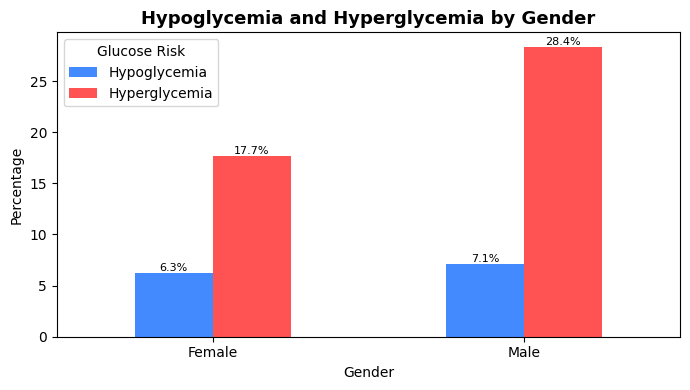

In [32]:
# Hypoglycemia and Hyperglycemia by Gender:

import pandas as pd
import matplotlib.pyplot as plt

# Create Hypoglycemia and Hyperglycemia columns
df["Hypoglycemia"] = df["Glucose"] < 70
df["Hyperglycemia"] = df["Glucose"] > 180

# Group by Gender
gender_risk = df.groupby("Gender")[[
    "Hypoglycemia",
    "Hyperglycemia"
]].mean() * 100

print(gender_risk)

# Create chart
ax = gender_risk.plot(
    kind="bar",
    figsize=(7,4),
    color=[
        "#448AFF",   # Blue for Hypoglycemia
        "#FF5252"    # Red for Hyperglycemia
    ]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        fontsize=8
    )

plt.title("Hypoglycemia and Hyperglycemia by Gender", fontsize=13, fontweight="bold")
plt.ylabel("Percentage")
plt.xlabel("Gender")

plt.xticks(rotation=0)
plt.legend(title="Glucose Risk")

plt.tight_layout()
plt.show()

#Q8: How does average glucose vary by hour of the day?

Understanding how glucose levels change throughout the day is clinically important for Type 1 Diabetes management. Glucose naturally fluctuates due to meals, insulin doses, physical activity, and sleep cycles. By analyzing average glucose by hour, we can identify peak risk periods and daily glucose patterns.

**Why this question is important:**
- Identifies the hours when glucose is highest (hyperglycemia risk)
- Identifies the hours when glucose is lowest (hypoglycemia risk)
- Helps detect the dawn phenomenon (early morning glucose rise)
- Supports meal timing and insulin dosing recommendations

**What we expect to find:**
- Higher glucose levels after typical meal times (breakfast, lunch, dinner)
- Lower glucose levels during overnight sleep hours
- A possible rise in early morning hours (dawn phenomenon)


=== AVERAGE GLUCOSE BY HOUR OF DAY ===
 Hour  Average Glucose
    0       142.560453
    1       138.743205
    2       137.456326
    3       138.166504
    4       139.117531
    5       138.296633
    6       136.677204
    7       135.232969
    8       136.351311
    9       140.178077
   10       147.361706
   11       148.144320
   12       140.531524
   13       133.149756
   14       130.808890
   15       136.698736
   16       136.960333
   17       138.748143
   18       146.168594
   19       152.558646
   20       150.639650
   21       150.666741
   22       151.333817
   23       147.372832

Highest glucose hour: 19:00 → 152.56 mg/dL
Lowest glucose hour:  14:00 → 130.81 mg/dL


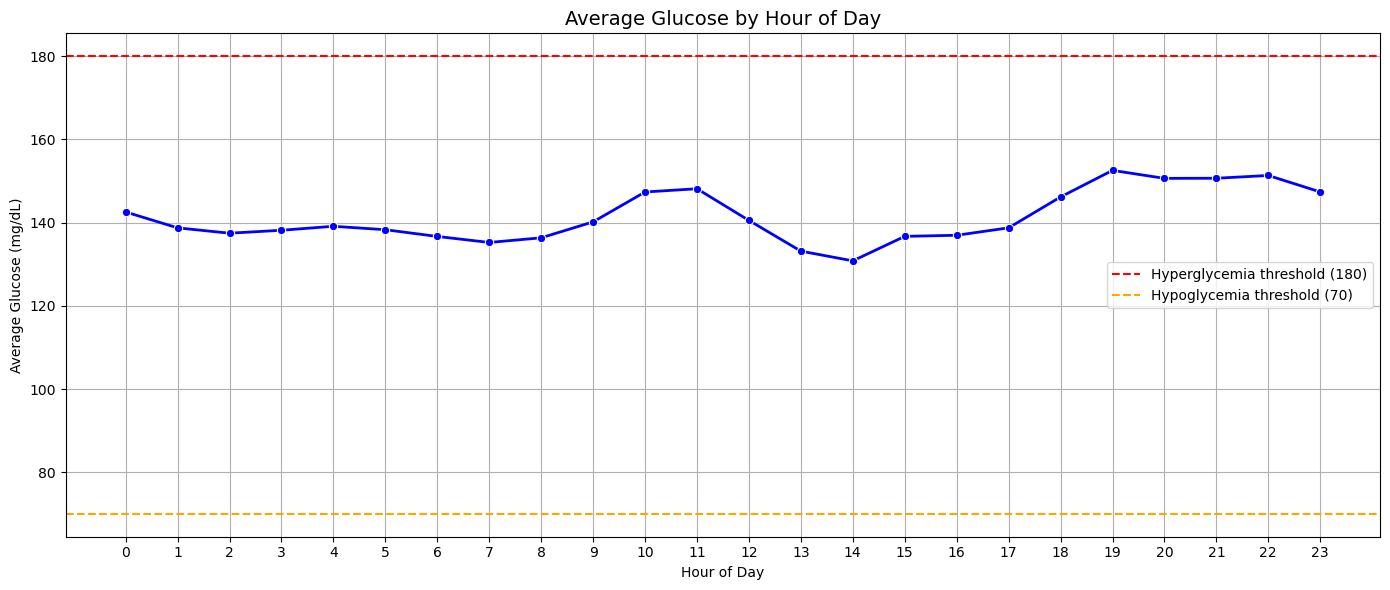

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (your path)
df = pd.read_excel(r"C:\Users\anitc\Downloads\TeamNumber_TeamName_cleaned_csv.xlsx")

# Create hour column from Time
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
df['Hour'] = df['Time'].dt.hour

# Calculate average glucose by hour
glucose_by_hour = df.groupby('Hour')['Glucose'].mean().reset_index()
glucose_by_hour.columns = ['Hour', 'Average Glucose']

# Print summary table
print("=== AVERAGE GLUCOSE BY HOUR OF DAY ===")
print(glucose_by_hour.to_string(index=False))
print(f"\nHighest glucose hour: {glucose_by_hour.loc[glucose_by_hour['Average Glucose'].idxmax(), 'Hour']}:00 → {glucose_by_hour['Average Glucose'].max():.2f} mg/dL")
print(f"Lowest glucose hour:  {glucose_by_hour.loc[glucose_by_hour['Average Glucose'].idxmin(), 'Hour']}:00 → {glucose_by_hour['Average Glucose'].min():.2f} mg/dL")

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=glucose_by_hour, x='Hour', y='Average Glucose', 
             marker='o', color='blue', linewidth=2)
plt.axhline(y=180, color='red', linestyle='--', label='Hyperglycemia threshold (180)')
plt.axhline(y=70, color='orange', linestyle='--', label='Hypoglycemia threshold (70)')
plt.title('Average Glucose by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Glucose (mg/dL)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Q9: Which patient has the highest and lowest average glucose?

Identifying patients with the highest and lowest average glucose levels helps pinpoint individuals who may need immediate clinical attention or whose glucose control is exceptionally good. This patient-level analysis is essential for personalized diabetes management.

**Why this question is important:**
- Identifies high-risk patients with consistently elevated glucose
- Identifies well-controlled patients for comparison
- Supports patient-specific recommendations
- Helps clinicians prioritize intervention strategies

**What we expect to find:**
- Some patients will show consistently high average glucose indicating poor glycemic control
- Some patients will show consistently low average glucose indicating good glycemic control
- Variability across patients reflects differences in lifestyle, insulin dosing, and demographics



=== AVERAGE GLUCOSE PER PATIENT ===
 Patient_ID  Average Glucose
         14       200.795244
         17       194.282669
          8       193.739271
         11       188.061765
          1       181.443726
          4       180.377984
          7       173.151991
         21       166.943660
          6       165.204585
         12       163.518724
         23       162.985267
         16       162.930477
         10       159.108579
         13       150.208344
          5       147.698624
         15       143.677664
          3       143.273519
         18       137.325153
          9       135.892648
         20       133.053330
         24       130.829946
         25       128.436109
         22       113.845607
          2       113.469664
         19       112.550584

🔴 Highest average glucose: 14.0 → 200.80 mg/dL
🟢 Lowest average glucose:  19.0 → 112.55 mg/dL


C:\Users\anitc\AppData\Local\Temp\ipykernel_18788\3366503198.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=patient_glucose, x='Patient_ID', y='Average Glucose', palette=colors)


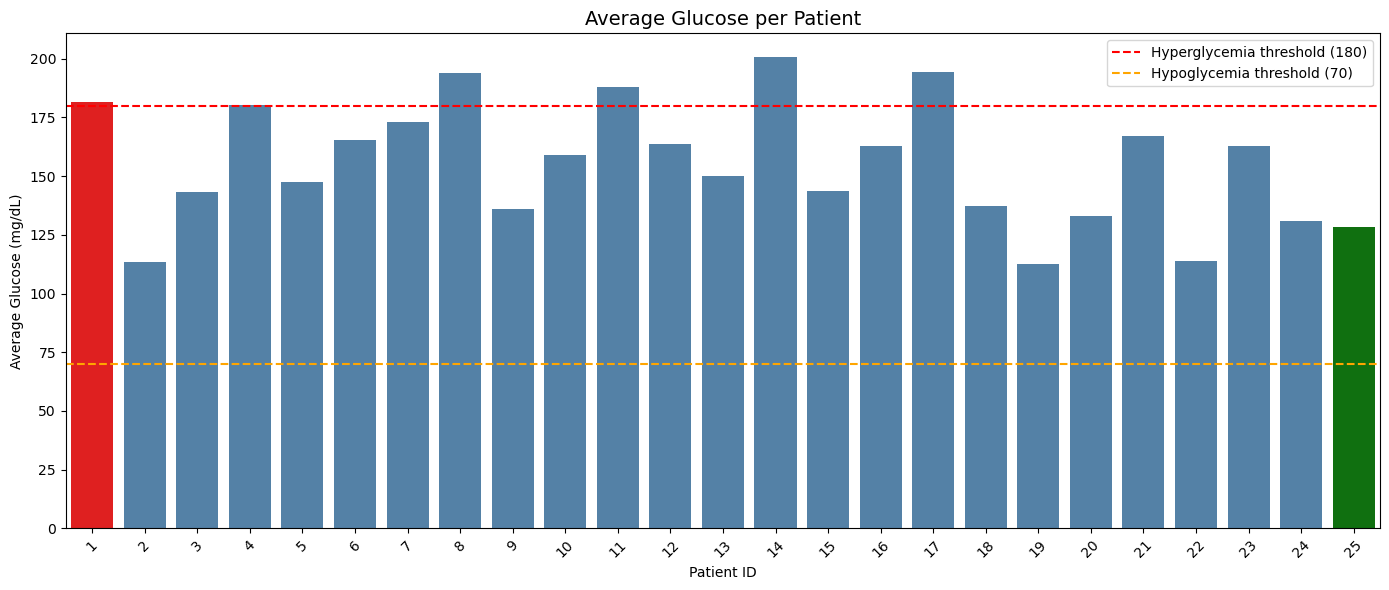

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (your path)
df = pd.read_excel(r"C:\Users\anitc\Downloads\TeamNumber_TeamName_cleaned_csv.xlsx")

# Calculate average glucose per patient using PID
patient_glucose = df.groupby('PID')['Glucose'].mean().reset_index()
patient_glucose.columns = ['Patient_ID', 'Average Glucose']
patient_glucose = patient_glucose.sort_values('Average Glucose', ascending=False).reset_index(drop=True)

# Print summary
print("=== AVERAGE GLUCOSE PER PATIENT ===")
print(patient_glucose.to_string(index=False))

print(f"\n🔴 Highest average glucose: {patient_glucose.iloc[0]['Patient_ID']} → {patient_glucose.iloc[0]['Average Glucose']:.2f} mg/dL")
print(f"🟢 Lowest average glucose:  {patient_glucose.iloc[-1]['Patient_ID']} → {patient_glucose.iloc[-1]['Average Glucose']:.2f} mg/dL")

# Plot
plt.figure(figsize=(14, 6))
colors = ['red' if x == patient_glucose.iloc[0]['Patient_ID'] 
          else 'green' if x == patient_glucose.iloc[-1]['Patient_ID'] 
          else 'steelblue' for x in patient_glucose['Patient_ID']]

sns.barplot(data=patient_glucose, x='Patient_ID', y='Average Glucose', palette=colors)
plt.axhline(y=180, color='red', linestyle='--', label='Hyperglycemia threshold (180)')
plt.axhline(y=70, color='orange', linestyle='--', label='Hypoglycemia threshold (70)')
plt.title('Average Glucose per Patient', fontsize=14)
plt.xlabel('Patient ID')
plt.ylabel('Average Glucose (mg/dL)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Glucose Stability During Low vs High Activity - Does activity level influence glucose stability?

It Shows:
variability,
density,
stability differences.

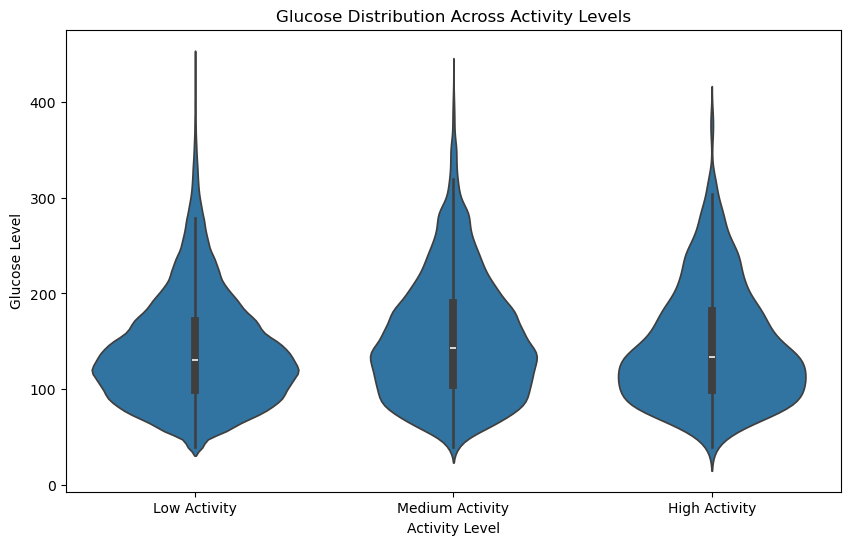

In [17]:
# Activity categories
df['activity_level'] = df['Steps'].apply(
    lambda x: 'Low Activity' if x < 100
    else 'Medium Activity' if x < 500
    else 'High Activity')

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='activity_level',
    y='Glucose'
)

plt.title("Glucose Distribution Across Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Glucose Level")

plt.show()

Observation : “Patients categorized under low activity levels exhibited greater glucose variability compared to highly active individuals, suggesting that regular physical activity may contribute to improved glucose stability.”

In [1]:
print("\n===================================")
print("DESCRIPTIVE ANALYSIS COMPLETED")
print("===================================")


DESCRIPTIVE ANALYSIS COMPLETED
